# How IPS works, one replication under the microscope

Fixed-level splitting ([`blueskycdarr/ips.py`](../blueskycdarr/ips.py), ADR 0008)
estimates a rare P(LoS) by nesting the event in shrinking shells of the running-minimum
separation, culling and resampling a particle cloud at each shell. This notebook runs
**one replication with N = 50 particles on the real engine** — every trajectory below is
BlueSky flying the aircraft, with the CDR chain acting on noisy perceived state — and
watches the machinery work:

1. the **initial cloud** flying toward the first shell,
2. the **cull**: who survives a shell, who ends first,
3. **resampling**: clones share their past and diverge only in future noise,
4. the descent **to loss of separation or termination**, and the estimate it yields.

The cell: crossing angle **90°**, `pos_ci95 = 40 m`, `vel_ci95 = 1 m/s`, reception 0.8,
latency 0.3 s — resolution active but sloppy, so breach behaviour is *graded* (see
[docs/rare-events.md](../docs/rare-events.md) for graded vs cliff cells). Ladder:
**95 → 85 → 70 → 50 m**, the last shell being the protected-zone radius. An independent
4 000-encounter Monte-Carlo pilot of this cell (seed 3) measured
**P(LoS) = 13/4000 ≈ 3.3 × 10⁻³**; hold that number for the end.

The notebook uses the estimator's own public pieces (`Particle`, `resample_level`, the
episode `advance` loop) and **its exact stream addressing**, so the final cell can show
that this walkthrough reproduces `estimate_rare_prob` *bit for bit*.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from blueskycdarr import Config, MULTIROTOR, PairwiseEncounter
from blueskycdarr.config import CommConfig, SimulationConfig, UncertaintyConfig
from blueskycdarr.engine import PairwiseWorld, reset_world
from blueskycdarr.episode import EpisodeStreams, advance, episode_context, init_episode
from blueskycdarr.ips import Particle, resample_level
from blueskycdarr.rng import child, generator, root_seed_sequence

# --- the cell -------------------------------------------------------------------------
DPSI, POS_CI95, VEL_CI95 = 90.0, 40.0, 1.0
N, LEVELS, SEED = 50, [95.0, 85.0, 70.0, 50.0], 4
RPZ = 50.0

SCENARIO = PairwiseEncounter(pairs=(1, 1), dpsi=DPSI, dcpa=0.0, tlos=20.0)
CONFIG = Config(
    uncertainty=UncertaintyConfig(pos_ci95=POS_CI95, vel_ci95=VEL_CI95),
    comm=CommConfig(reception_prob=0.8, latency_s=0.3),
    simulation=SimulationConfig(t_max=90.0),
)
ctx = episode_context(SCENARIO.n_pairs, MULTIROTOR, CONFIG)

# the estimator's stream tree, addressed identically (ips.ips_once):
rep_seq = child(root_seed_sequence(SEED), 0)          # replication 0
init_seq, evolve_seq = child(rep_seq, 0), child(rep_seq, 1)

# --- plotting style (palette: validated defaults; blue/orange/aqua + neutral grays) ---
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GRAY, INK, MUTED, RED = "#b6b5ae", "#0b0b0b", "#52514e", "#e34948"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.edgecolor": MUTED,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": MUTED,
    "ytick.color": MUTED, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#eeedea", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "figure.constrained_layout.use": True,
})

_LAT0, _LON0, _M_PER_DEG = 52.3, 4.7, 111_320.0   # the engine's spawn-grid origin

def _en(lat, lon):
    return (lon - _LON0) * _M_PER_DEG * np.cos(np.radians(_LAT0)), (lat - _LAT0) * _M_PER_DEG

def _levels_on(ax, levels=LEVELS, bold=None):
    for d in levels:
        is_rpz = d == RPZ
        ax.axhline(d, color=RED if is_rpz else MUTED,
                   lw=1.6 if d == bold else 0.9,
                   ls="--", alpha=0.9 if (is_rpz or d == bold) else 0.55, zorder=1)
        ax.annotate(f"{d:g} m" + (" = rpz" if is_rpz else ""),
                    xy=(1.0, d), xycoords=("axes fraction", "data"),
                    xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=8.5, color=RED if is_rpz else MUTED)


The two helpers below are the estimator's evolution leg with a **trajectory recorder**
attached. `advance` already takes an observer hook (`recorder`) that is handed
`(t, truth, pair_distances)` once per step and cannot influence the run — we use it to
keep, per particle, the time series of separation and both aircraft's positions. A
particle is exactly the estimator's own value: an engine half (`WorldSnapshot`, or
`None` once the encounter has ended) beside an episode half (`EpisodeState`). Cloning a
particle's *trajectory record* mirrors cloning the particle: the child inherits the
parent's history and appends its own leg.


In [2]:
world = None  # the one live engine slot every particle passes through

def _fly(state, streams, target, traj):
    """Advance until the running minimum crosses `target` or the encounter ends,
    recording (t, separation, own E/N, intruder E/N) each step."""
    def rec(t, truth, distances):
        oe, on = _en(truth.lat[0], truth.lon[0])
        ie, inn = _en(truth.lat[1], truth.lon[1])
        traj.append((t, float(distances[0]), oe, on, ie, inn))
    running = not state.ended
    while running and float(state.min_sep[0]) > target:
        running = advance(world, ctx, state, streams, recorder=rec)
    return Particle(world=None if state.ended else world.snapshot(), episode=state)

def spawn_and_fly(i, target, level_seq):
    """Level 1: materialise particle i (its own geometry + broadcast phase) and fly."""
    global world
    seed = child(init_seq, i)
    geometry = SCENARIO.draw_geometry(generator(child(seed, 0)))
    world = PairwiseWorld(SCENARIO, geometry, MULTIROTOR, CONFIG.conflict, CONFIG.simulation)
    state = init_episode(world, ctx, EpisodeStreams.from_episode_seq(seed))
    traj = []
    p = _fly(state, EpisodeStreams.from_episode_seq(child(level_seq, i)), target, traj)
    return p, traj

def evolve_clone(p, traj, target, streams):
    """Levels 2+: restore the frozen world, copy the episode half, fly on fresh streams.
    Ended or already-overshot particles never touch the engine again."""
    if p.world is None or p.min_sep <= target:
        return p, list(traj)
    world.restore(p.world)
    new_traj = list(traj)
    return _fly(p.episode.copy(), streams, target, new_traj), new_traj


## 1 · The initial cloud: 50 particles fly to the first shell

Each particle is **one whole encounter**: its own geometry draw and broadcast phase
(sampled from its seed, laid out exactly like a Monte-Carlo episode seed), spawned
fresh into the engine and flown until its running-minimum separation crosses the first
shell (95 m) — or until the encounter ends first (resolved, cleared, settled).

Left: the plan view — every ownship flies north, every intruder cuts across at 90°;
the wiggles are resolution manoeuvres commanded off noisy perceived state. Right: the
same 50 particles as IPS sees them — separation against time, descending toward the
ladder.


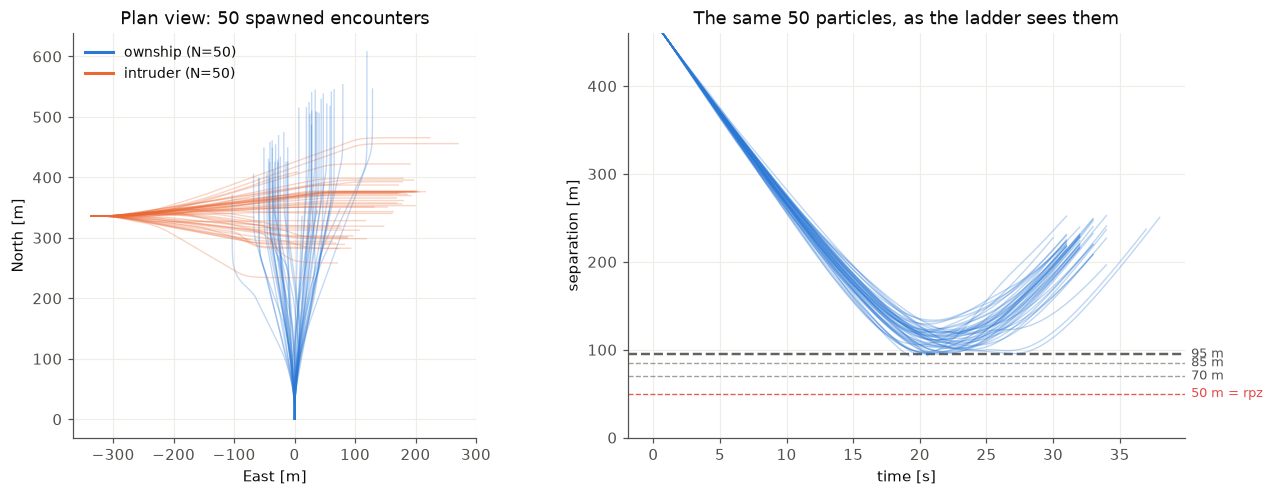

In [3]:
level1_seq = child(evolve_seq, 0)
cloud, trajs = [], []
for i in range(N):
    p, traj = spawn_and_fly(i, LEVELS[0], level1_seq)
    cloud.append(p)
    trajs.append(traj)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.6, 4.4))
for traj in trajs:
    a = np.asarray(traj)
    ax0.plot(a[:, 2], a[:, 3], color=BLUE, lw=0.9, alpha=0.28, zorder=3)
    ax0.plot(a[:, 4], a[:, 5], color=ORANGE, lw=0.9, alpha=0.28, zorder=3)
ax0.plot([], [], color=BLUE, lw=2, label="ownship (N=50)")
ax0.plot([], [], color=ORANGE, lw=2, label="intruder (N=50)")
ax0.set(xlabel="East [m]", ylabel="North [m]", title="Plan view: 50 spawned encounters")
ax0.set_aspect("equal")
ax0.legend(frameon=False, loc="upper left", fontsize=9)

for traj in trajs:
    a = np.asarray(traj)
    ax1.plot(a[:, 0], a[:, 1], color=BLUE, lw=0.9, alpha=0.30, zorder=3)
_levels_on(ax1, bold=LEVELS[0])
ax1.set(xlabel="time [s]", ylabel="separation [m]",
        title="The same 50 particles, as the ladder sees them")
ax1.set_ylim(0, 460)
plt.show()


## 2 · The cull: survivors and the dropped

A particle **survives** the shell if its running minimum reached 95 m before the
encounter closed; it is **dropped** if the encounter ended first — resolved wide,
cleared, and settled without ever coming that close. Survivor legs stop *at* the shell
(the estimator freezes them there, one step past the crossing observation); dropped
legs run to their natural end.


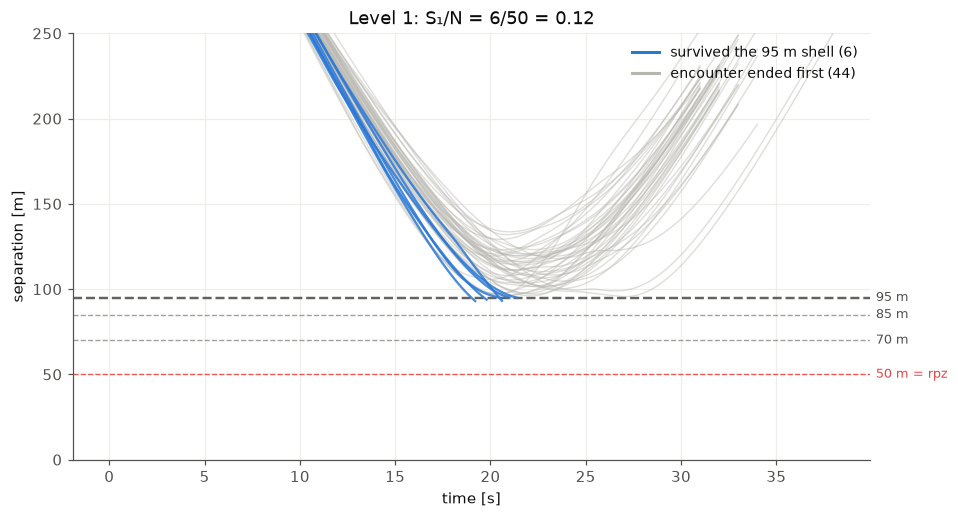

survival fraction S1/N = 6/50 = 0.120


In [4]:
survived = [p.min_sep <= LEVELS[0] for p in cloud]

fig, ax = plt.subplots(figsize=(8.6, 4.6))
for p, traj, s in zip(cloud, trajs, survived):
    a = np.asarray(traj)
    ax.plot(a[:, 0], a[:, 1], color=BLUE if s else GRAY,
            lw=1.5 if s else 0.9, alpha=0.85 if s else 0.45, zorder=3 if s else 2)
_levels_on(ax, bold=LEVELS[0])
ax.plot([], [], color=BLUE, lw=2, label=f"survived the 95 m shell ({sum(survived)})")
ax.plot([], [], color=GRAY, lw=2, label=f"encounter ended first ({N - sum(survived)})")
ax.legend(frameon=False, loc="upper right", fontsize=9)
ax.set(xlabel="time [s]", ylabel="separation [m]",
       title=f"Level 1: S₁/N = {sum(survived)}/{N} = {sum(survived) / N:.2f}")
ax.set_ylim(0, 250)
plt.show()
print(f"survival fraction S1/N = {sum(survived)}/{N} = {sum(survived) / N:.3f}")


## 3 · Resampling: clones share their past, diverge in their future

The survivors are drawn **with replacement** back up to N = 50 — this is the
estimator's own `resample_level`, on the estimator's own resampling stream. A clone is
*not a copy*: all clones of one survivor **share the same frozen particle** (the same
`WorldSnapshot`, the same episode state, the same history — left panel). What
separates them is handed out only when they fly again: **fresh forward-noise streams,
one bundle per clone per level**. The right panel is that contract made visible: each
family restarts from its parent's freeze point as one curve and fans apart step by
step as different GNSS noise and different broadcast luck accumulate.


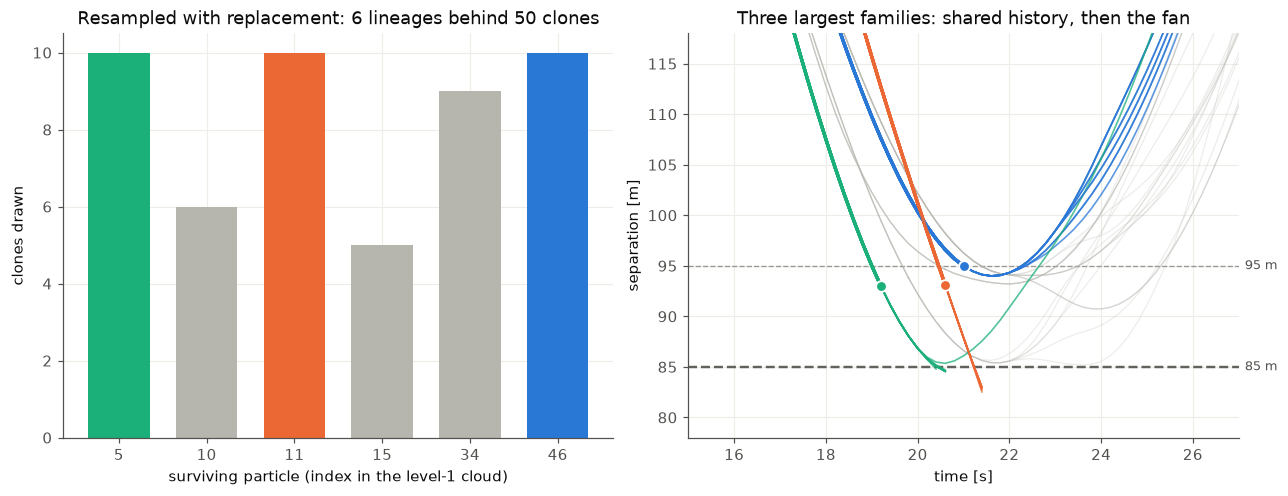

level 2 (85 m): 19/50 survived


In [5]:
fraction1, cloud2, lineages1 = resample_level(cloud, LEVELS[0], N, child(level1_seq, N))
parent_of = {id(p): j for j, p in enumerate(cloud)}
clone_parent = [parent_of[id(p)] for p in cloud2]
trajs2_in = [list(trajs[j]) for j in clone_parent]

# fly every clone to the second shell (85 m) on its own fresh streams
level2_seq = child(evolve_seq, 1)
cloud2_out, trajs2 = [], []
for i, (p, traj) in enumerate(zip(cloud2, trajs2_in)):
    q, t2 = evolve_clone(p, traj, LEVELS[1],
                         EpisodeStreams.from_episode_seq(child(level2_seq, i)))
    cloud2_out.append(q)
    trajs2.append(t2)

parents, counts = np.unique(clone_parent, return_counts=True)
top3 = parents[np.argsort(counts)[::-1][:3]]
family_color = dict(zip(top3, (BLUE, ORANGE, AQUA)))

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.6, 4.4))
bar_colors = [family_color.get(p, GRAY) for p in parents]
ax0.bar([str(p) for p in parents], counts, color=bar_colors, width=0.7)
ax0.set(xlabel="surviving particle (index in the level-1 cloud)", ylabel="clones drawn",
        title=f"Resampled with replacement: {len(parents)} lineages behind {N} clones")

split_len = {j: len(trajs[j]) for j in parents}
for i, (traj, j) in enumerate(zip(trajs2, clone_parent)):
    a = np.asarray(traj)
    c = family_color.get(j, GRAY)
    faded = j not in family_color
    cut = split_len[j]
    ax1.plot(a[:cut, 0], a[:cut, 1], color=c, lw=2.0 if not faded else 0.8,
             alpha=0.9 if not faded else 0.25, zorder=4 if not faded else 2)
    ax1.plot(a[cut - 1:, 0], a[cut - 1:, 1], color=c, lw=1.1 if not faded else 0.8,
             alpha=0.75 if not faded else 0.25, zorder=4 if not faded else 2)
for j in top3:
    a = np.asarray(trajs[j])
    ax1.plot(a[-1, 0], a[-1, 1], "o", color=family_color[j], ms=7, zorder=5,
             markeredgecolor="white", markeredgewidth=1.2)
_levels_on(ax1, levels=LEVELS[:2], bold=LEVELS[1])
ax1.set(xlabel="time [s]", ylabel="separation [m]",
        title="Three largest families: shared history, then the fan")
ax1.set_xlim(15, 27)
ax1.set_ylim(78, 118)
plt.show()
print(f"level 2 (85 m): {sum(p.min_sep <= LEVELS[1] for p in cloud2_out)}/{N} survived")


## 4 · Down the ladder, to loss of separation or termination

The same cull-and-resample loop runs the remaining shells (70 m, then the 50 m
protected-zone boundary itself). A particle whose encounter has ended carries no
engine state at all — it rides through later resamplings as a closed value, surviving
only if its accumulated minimum already overshoots the next shell. The figure shows
everything this replication explored (gray) and, in blue, the **complete lineages of
the particles that reached loss of separation** — each one a full flight from t = 0
through every shell to below 50 m, stitched from its inherited history plus every leg
its ancestors flew.


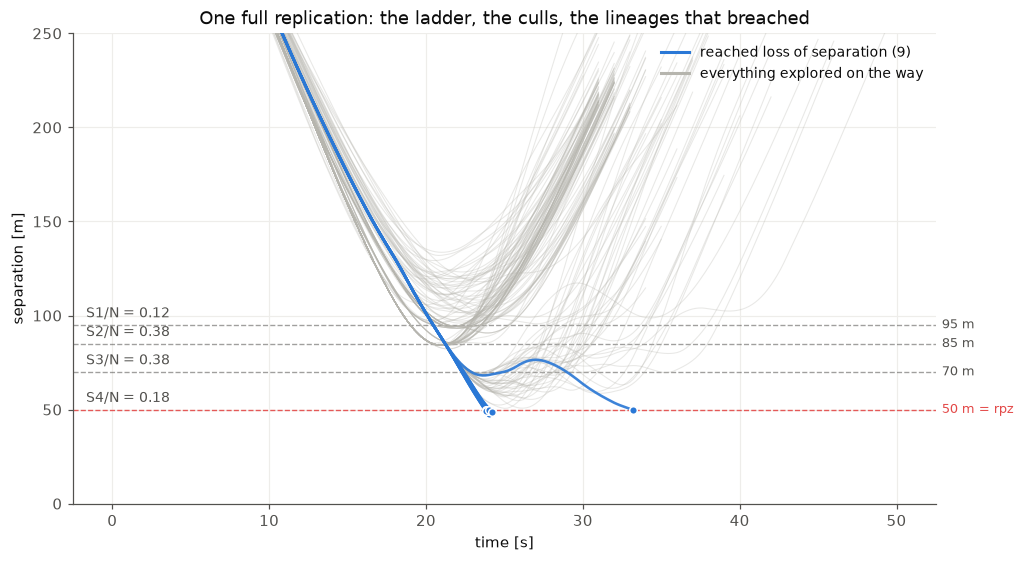

In [6]:
survival = [fraction1, sum(p.min_sep <= LEVELS[1] for p in cloud2_out) / N]
clouds, trajs_now = cloud2_out, trajs2
explored = list(trajs) + list(trajs2)

for k, target in enumerate(LEVELS[2:], start=2):
    level_seq = child(evolve_seq, k)
    frac, resampled, _ = resample_level(clouds, LEVELS[k - 1], N, child(child(evolve_seq, k - 1), N))
    survival[k - 1] = frac  # the estimator resamples on the *previous* level's stream
    parent_of = {id(p): j for j, p in enumerate(clouds)}
    traj_in = [list(trajs_now[parent_of[id(p)]]) for p in resampled]
    clouds, trajs_now = [], []
    for i, (p, traj) in enumerate(zip(resampled, traj_in)):
        q, t_out = evolve_clone(p, traj, target,
                                EpisodeStreams.from_episode_seq(child(level_seq, i)))
        clouds.append(q)
        trajs_now.append(t_out)
    explored += trajs_now
    survival.append(sum(p.min_sep <= target for p in clouds) / N)

reset_world()  # clear the engine: the campaign is over

fig, ax = plt.subplots(figsize=(9.2, 5.0))
for traj in explored:
    a = np.asarray(traj)
    ax.plot(a[:, 0], a[:, 1], color=GRAY, lw=0.7, alpha=0.30, zorder=2)
reached = [(p, t) for p, t in zip(clouds, trajs_now) if p.min_sep <= RPZ]
for p, traj in reached:
    a = np.asarray(traj)
    ax.plot(a[:, 0], a[:, 1], color=BLUE, lw=1.7, alpha=0.9, zorder=4)
    ax.plot(a[-1, 0], a[-1, 1], "o", color=BLUE, ms=5, zorder=5,
            markeredgecolor="white", markeredgewidth=1.0)
_levels_on(ax)
for k, (d, s) in enumerate(zip(LEVELS, survival)):
    ax.annotate(f"S{k + 1}/N = {s:.2f}", xy=(0.015, d), xycoords=("axes fraction", "data"),
                xytext=(0, 5), textcoords="offset points", fontsize=9, color=MUTED)
ax.plot([], [], color=BLUE, lw=2, label=f"reached loss of separation ({len(reached)})")
ax.plot([], [], color=GRAY, lw=2, label="everything explored on the way")
ax.legend(frameon=False, loc="upper right", fontsize=9)
ax.set(xlabel="time [s]", ylabel="separation [m]",
       title="One full replication: the ladder, the culls, the lineages that breached")
ax.set_ylim(0, 250)
plt.show()


## The estimate — and the proof this was the real thing

The replication's estimate is the product of its survival fractions,
P̂ = Π<sub>k</sub> S<sub>k</sub>/N. Because this notebook used the estimator's exact
stream addressing, calling the packaged `estimate_rare_prob` with the same seed and
ladder must reproduce **the identical survival tuple** — the walkthrough above *is*
the estimator, opened up.


In [7]:
from blueskycdarr.ips import estimate_rare_prob

p_hat = float(np.prod(survival))
for d, s in zip(LEVELS, survival):
    print(f"  shell {d:5.1f} m   S/N = {s:.3f}")
print(f"\n  P̂ = product = {p_hat:.4g}   (one replication, N={N})")
print(f"  MC pilot of this cell: 13/4000 = {13 / 4000:.4g}")

est = estimate_rare_prob(SCENARIO, MULTIROTOR, CONFIG,
                         levels=LEVELS, n_particles=N, reps=1, seed=SEED)
print("\npackaged estimator, same seed and ladder:")
print(est)
assert est.reps[0].survival == tuple(survival), "walkthrough diverged from the estimator!"
print("\nbit-for-bit identical to the walkthrough ✓")


  shell  95.0 m   S/N = 0.120
  shell  85.0 m   S/N = 0.380
  shell  70.0 m   S/N = 0.380
  shell  50.0 m   S/N = 0.180

  P̂ = product = 0.003119   (one replication, N=50)
  MC pilot of this cell: 13/4000 = 0.00325



packaged estimator, same seed and ladder:
IPSEstimate  P(LoS) 0.00312 over 1 replications
  survival   levels (95, 85, 70, 50) m | mean per level 0.12, 0.38, 0.38, 0.18
  collapsed  0 of 1 replications
  lineages   9 distinct survivors behind the final clouds (per-replication record: reps)

bit-for-bit identical to the walkthrough ✓


### Things to try

- **Change the seed and watch a collapse.** N = 50 is deliberately small — at this
  cloud size roughly *half* the seeds collapse at some shell (seed 11, for instance,
  reaches 70 m and then loses everyone): zero survivors, P̂ = 0, `collapsed_at` set —
  the estimator's signal that the cloud or the spacing is too thin, never a measured
  zero. This is exactly why production runs use N ≳ 128 *and* average independent
  replications.
- **Move the shells.** Push the last level below 50 m (severity of breach: the
  1e-4 study in `results/ips_mc_comparison/` laddered to 0.6 m) or space the shells
  further apart and watch the survival fractions thin out.
- **Change the cell.** Drop `POS_CI95` to 10 m: the CDR gets precise, failures become
  a discrete never-detected mode, the min-sep distribution turns bimodal, and
  fixed-level ladders start to struggle — the *cliff* regime of
  [docs/rare-events.md](../docs/rare-events.md).
- **More replications.** One replication has spread that a single number hides;
  `estimate_rare_prob(..., reps=8, n_jobs=8)` averages independent ladders — the
  production recipe, and the parallel axis (`scripts/validation/` runs the full
  MC-vs-IPS campaign).
